# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import linalg as LA
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

# Generate data

Covariance matrix (true):
[[4.   2.25]
 [2.25 2.25]]


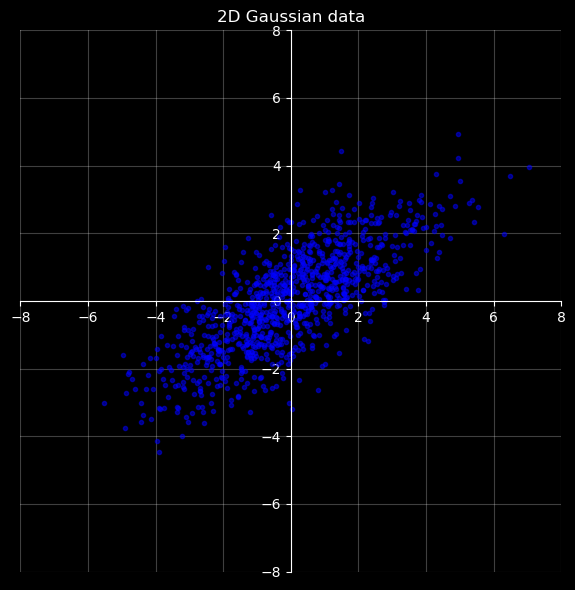

,x,y
0,0.249394,-0.362106
1,1.365347,0.179236
2,0.656093,-1.002322
3,2.437354,1.197749
4,0.242430,1.453937


In [8]:
# -----------------------------
# User-defined parameters
# -----------------------------
sigma_x = 2.0        # std of x
sigma_y = 1.5        # std of y
rho     = 0.75        # Pearson correlation (-1 to 1)

# -----------------------------
# Construct covariance matrix
# -----------------------------
cov_true = np.array([
    [sigma_x**2,        rho * sigma_x * sigma_y],
    [rho * sigma_x * sigma_y,  sigma_y**2]
])

print("Covariance matrix (true):")
print(cov_true)

# -----------------------------
# Sample from the distribution
# -----------------------------
n_samp = 1000
df = pd.DataFrame(
    np.random.multivariate_normal(
        mean=[0, 0],
        cov=cov_true,
        size=n_samp
    ),
    columns=["x", "y"]
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(df.x.values, df.y.values, 'b.', alpha=0.5)

# Centered axes spines at (0,0)
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")

# Cosmetics
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-8,8)
ax.set_ylim(-8,8)
ax.grid(True, alpha=0.25)
ax.set_title("2D Gaussian data")

plt.tight_layout()
plt.show()

display(df.head(5))

# Find eigenvalues / vectors of covariance matrix

In [9]:
# -----------------------------
# Covariance + eigendecomposition (sorted largest -> smallest)
# -----------------------------
cov = df.cov().values

print("Covariance matrix (true):")
print(cov_true)
print()
print("Covariance matrix (computed):")
print(cov)
print()

w, v = LA.eig(cov)  # columns of v are eigenvectors
idx = np.argsort(w)[::-1]
w = w[idx]
v = v[:, idx]

print("Eigenvalues (sorted):")
print(w)
print()
print("Eigenvectors (sorted columns):")
print(v)

Covariance matrix (true):
[[4.   2.25]
 [2.25 2.25]]

Covariance matrix (computed):
[[3.89414865 2.24430627]
 [2.24430627 2.26921855]]

Eigenvalues (sorted):
[5.46852462 0.69484257]

Eigenvectors (sorted columns):
[[ 0.81865544 -0.57428501]
 [ 0.57428501  0.81865544]]


# Display principal component axes

PC1 axis: [0.819 0.574]
PC2 axis: [-0.574  0.819]


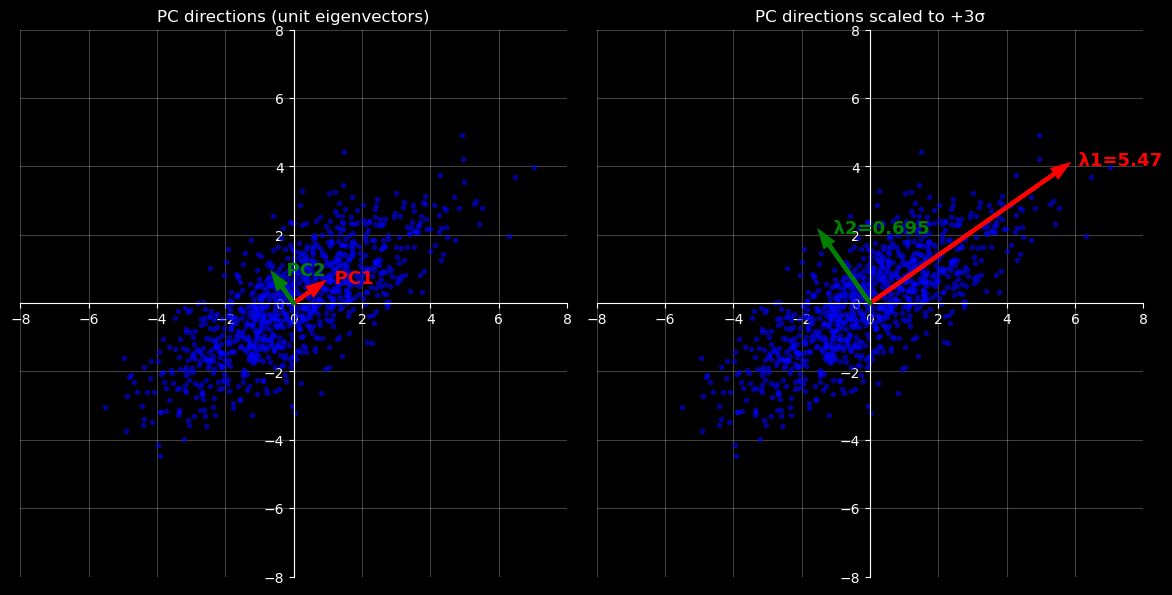

In [10]:
print("PC1 axis:", np.round(v[:, 0], 3))
print("PC2 axis:", np.round(v[:, 1], 3))

# -----------------------------
# Plot: side-by-side (positive PC directions only)
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

titles = [
    "PC directions (unit eigenvectors)",
    "PC directions scaled to +3σ"
]

scales = [
    1.0,                          # unit vectors
    3.0 * np.sqrt(w)              # +3σ scaling
]

for ax, title, scale in zip(axes, titles, scales):

    # Data cloud
    ax.plot(df.x.values, df.y.values, "b.", alpha=0.5)

    # Centered axes spines
    ax.spines["left"].set_position("zero")
    ax.spines["bottom"].set_position("zero")
    ax.spines["right"].set_color("none")
    ax.spines["top"].set_color("none")
    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

    # Draw PC axes (positive direction only)
    for k, color in [(0, "red"), (1, "green")]:
        vec = v[:, k]

        if np.isscalar(scale):
            length = scale
        else:
            length = scale[k]

        dx, dy = length * vec[0], length * vec[1]

        ax.arrow(
            0, 0, dx, dy,
            head_width=0.25,
            length_includes_head=True,
            linewidth=3,
            color=color,
            zorder=5
        )

        label = f"PC{k+1}" if np.isscalar(scale) else f"λ{k+1}={w[k]:.3g}"
        ax.text(dx, dy, f"  {label}", fontsize=13, color=color, weight="bold")

    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-8, 8)
    ax.set_ylim(-8, 8)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# Find a point's coordinates in PC space

In [11]:
# Centered axes spines at (0,0)
def center_spines(ax):
    ax.spines["left"].set_position("zero")
    ax.spines["bottom"].set_position("zero")
    ax.spines["right"].set_color("none")
    ax.spines["top"].set_color("none")
    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

# Projection of point p onto the line through origin spanned by unit vector u
def proj_onto_axis(p, u):
    a = float(u.T @ p)      # scalar coordinate along u (since u is unit)
    return a * u, a         # projected vector, scalar

# Oriented perpendicular direction for drawing "drop" lines
def perp(u):
    return np.array([-u[1], u[0]], dtype=float)

Orig coords = [-2. -4.]
PC coords   = [-3.9344509228739373, -2.1260517245580886]


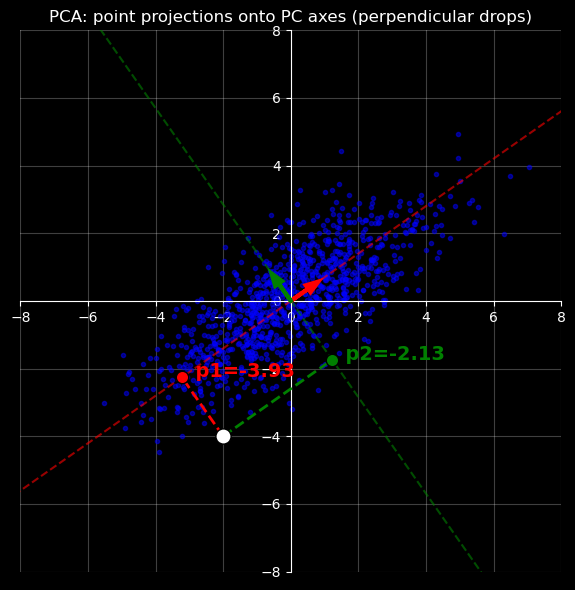

In [12]:
p = np.array([-2.0, -4.0])

# -----------------------------
# Compute projections
# -----------------------------
u1 = v[:, 0] / np.linalg.norm(v[:, 0])
u2 = v[:, 1] / np.linalg.norm(v[:, 1])

p1, a1 = proj_onto_axis(p, u1)  # projection point on PC1 axis
p2, a2 = proj_onto_axis(p, u2)  # projection point on PC2 axis

print(f"Orig coords = {p}")
print(f"PC coords   = [{a1}, {a2}]")

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(df.x.values, df.y.values, "b.", alpha=0.5)

center_spines(ax)

# Draw principal axes as unit arrows (just directions)
for u, color, label in [(u1, "red", "PC1"), (u2, "green", "PC2")]:
    ax.arrow(
        0, 0, u[0], u[1],
        head_width=0.25,
        length_includes_head=True,
        linewidth=3,
        color=color,
        zorder=5
    )

# Draw thin dashed lines extending along PC axes
L = 10  # length in each direction

for u, color in [(u1, "red"), (u2, "green")]:
    ax.plot(
        [-L*u[0], L*u[0]],
        [-L*u[1], L*u[1]],
        linestyle="--",
        linewidth=1.5,
        color=color,
        alpha=0.6,
        zorder=2
    )


# Highlight chosen point
ax.scatter([p[0]], [p[1]], s=120, color="white", edgecolor="black", zorder=10)

# Draw projection "drop" lines: from p to its perpendicular foot on each axis
# Use dashed lines so they don't obscure the cloud.
ax.plot([p[0], p1[0]], [p[1], p1[1]], linestyle="--", linewidth=2, color="r", zorder=9)
ax.plot([p[0], p2[0]], [p[1], p2[1]], linestyle="--", linewidth=2, color="g", zorder=9)

# Mark the feet of the perpendiculars
ax.scatter([p1[0]], [p1[1]], s=80, color="r", edgecolor="black", zorder=11)
ax.scatter([p2[0]], [p2[1]], s=80, color="g", edgecolor="black", zorder=11)

# Labels near the feet
ax.text(p1[0], p1[1], f"  p1={a1:.3g}", color="r", fontsize=14, weight="bold", zorder=12)
ax.text(p2[0], p2[1], f"  p2={a2:.3g}", color="g", fontsize=14, weight="bold", zorder=12)

# Cosmetics
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-8,8)
ax.set_ylim(-8,8)
ax.grid(True, alpha=0.25)
ax.set_title("PCA: point projections onto PC axes (perpendicular drops)")

plt.tight_layout()
plt.show()